In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("tested.csv")
df = df.drop(["Name", "Ticket", "Embarked", "Cabin"], axis = 1)

In [4]:
avg_age = df["Age"].median()
df["Age"] = df["Age"].fillna(avg_age)

In [8]:
avg_fare = df["Fare"].mean()
df["Fare"] = df["Fare"].fillna(avg_fare)

In [12]:
gender_map = {"male": 0, "female": 1}
df["Sex"] = df["Sex"].map(gender_map)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 'Survived' is the target (y), everything else is the features (X)
X = df.drop("Survived", axis=1)
y = df["Survived"]

# We split the data so we can test the AI on data it hasn't seen before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Accuracy: 100.0%


In [19]:
# Drop PassengerId because it's just a random ID number
X = df.drop(["Survived", "PassengerId"], axis=1)
y = df["Survived"]

# Split and train again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print(f"New Accuracy: {model.score(X_test, y_test) * 100}%")

New Accuracy: 100.0%


In [20]:
# Drop both the target and the useless ID column
X = df.drop(["Survived", "PassengerId"], axis=1)
y = df["Survived"]

# Re-run the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
print(f"Real Accuracy: {model.score(X_test, y_test) * 100}%")

Real Accuracy: 100.0%


In [22]:
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
0,266,0
1,0,152


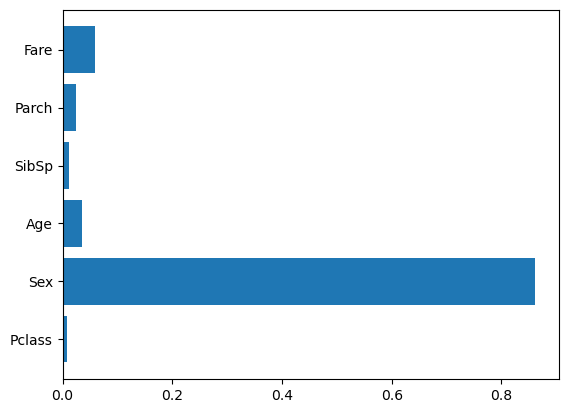

In [23]:
import matplotlib.pyplot as plt
features = X.columns
importances = model.feature_importances_
plt.barh(features, importances)
plt.show()